In [1]:
import matplotlib.pyplot as plt

import numpy as np
import anndata as ad
import polars as pl
import sys

import src as scit

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [18]:
rep1_s = "~/Dokument/fragments/nanoCT_rep1_fragments"
rep2_s = "~/Dokument/fragments/nanoCT_rep2_fragments"

dm6 = scit.tl.get_genome_dict('DM6')
rep1ac = scit.ld.fragments(
    f"{rep1_s}/emb8_10/Nanoscope_output/H3K27ac_CCTATCCT/cellranger/outs/fragments.tsv.gz",
    dm6,
    ignore_missing_chr=True
)
rep2ac = scit.ld.fragments(
    f"{rep2_s}/droso_emb_8_10/H3K27ac_ATAGAGGC/cellranger/outs/fragments.tsv.gz",
    dm6,
    ignore_missing_chr=True
)


Info: Reading fragments file with 11161920 lines...
Info: Number of unique barcodes is 114477...
Info: Ignoring chromosomes ['chrUn_CP007081v1' 'chrUn_CP007120v1' 'chrUn_DS483646v1'
 'chrUn_DS484581v1' 'chrY_DS483875v1_random' 'chrY_DS484142v1_random'
 'chrY_DS484530v1_random' 'chrY_DS484909v1_random'
 'chrY_DS485423v1_random' 'chrY_DS485523v1_random'
 'chrY_DS485938v1_random']


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:43<00:00,  5.13it/s]


Info: Reading fragments file with 6423343 lines...
Info: Number of unique barcodes is 76327...
Info: Found no chromosomes starting with 'chr' in fragments. Mapping chromosome names with lambda x: 'chr' + x. If you want to avoid this, set chr_name_insert_prefix = False
Info: Ignoring chromosomes ['chr211000022278760' 'chr211000022280328'
 'chrUnmapped_Scaffold_8_D1580_D1567']


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:21<00:00, 10.34it/s]


In [19]:
rep1me = scit.ld.fragments(
    f"{rep1_s}/emb8_10/Nanoscope_output/H3K27me3_ATAGAGGC/cellranger/outs/fragments.tsv.gz",
    dm6,
    ignore_missing_chr=True
)
rep2me = scit.ld.fragments(
    f"{rep2_s}/droso_emb_8_10/H3K27me3/cellranger/outs/fragments.tsv.gz",
    dm6,
    ignore_missing_chr=True
)


Info: Reading fragments file with 2828794 lines...
Info: Number of unique barcodes is 51953...
Info: Ignoring chromosomes ['chrUn_CP007081v1' 'chrUn_CP007120v1' 'chrUn_DS483646v1'
 'chrUn_DS483910v1' 'chrUn_DS484581v1' 'chrX_DS483995v1_random'
 'chrY_DS484530v1_random' 'chrY_DS485423v1_random'
 'chrY_DS485938v1_random']


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:10<00:00, 21.99it/s]


Info: Reading fragments file with 4361159 lines...
Info: Number of unique barcodes is 55196...
Info: Found no chromosomes starting with 'chr' in fragments. Mapping chromosome names with lambda x: 'chr' + x. If you want to avoid this, set chr_name_insert_prefix = False
Info: Ignoring chromosomes ['chr211000022278760' 'chr211000022280328'
 'chrUnmapped_Scaffold_8_D1580_D1567']


100%|█████████████████████████████████████████████████████████████████████████████████████████████████| 225/225 [00:13<00:00, 16.17it/s]


In [20]:
# Stack datas into one AnnData
rep1 = scit.tl.stack_adata([rep1ac, rep1me], ['acet', 'meth'])
rep2 = scit.tl.stack_adata([rep2ac, rep2me], ['acet', 'meth'])
rep1.write_h5ad('private/data/clean_method/early_rep1.h5ad')
rep2.write_h5ad('private/data/clean_method/early_rep2.h5ad')

Info: found 35310 obs shared between all adatas...
Info: found 27513 var shared between all adatas...


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_combine.py:61: ImplicitModificationWarning: Setting element `.layers['acet']` of view, initializing view as actual.
  _adata.layers[layer_names[i]] = adatas[i].X.copy()


Info: found 21916 obs shared between all adatas...
Info: found 27513 var shared between all adatas...


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_combine.py:61: ImplicitModificationWarning: Setting element `.layers['acet']` of view, initializing view as actual.
  _adata.layers[layer_names[i]] = adatas[i].X.copy()


In [2]:
rep1 = ad.read_h5ad('private/data/clean_method/early_rep1.h5ad')
rep2 = ad.read_h5ad('private/data/clean_method/early_rep2.h5ad')

Info: Added acet counts metadata
Info: Added meth counts metadata
Info: Added acet counts metadata
Info: Added meth counts metadata


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


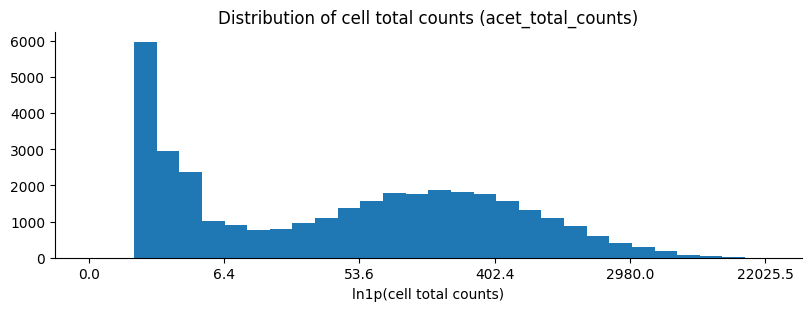

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


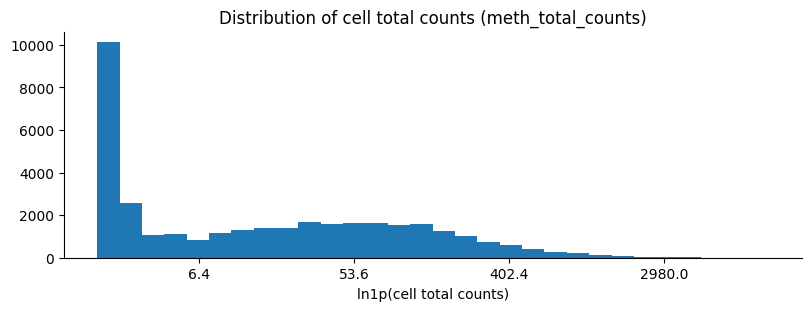

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


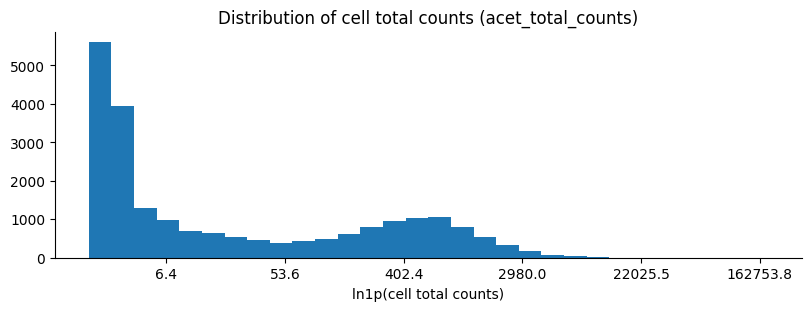

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


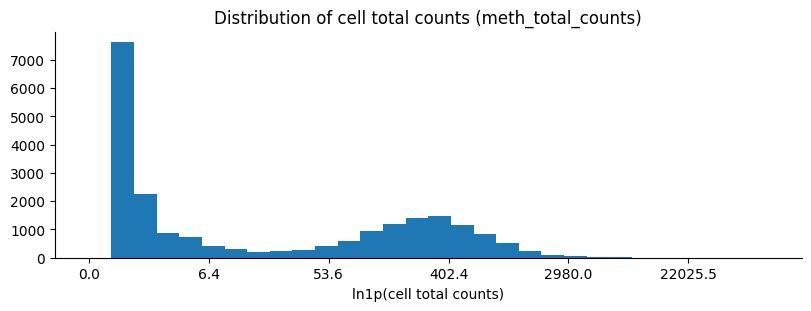

In [3]:
scit.tl.add_metadata(rep1, ['acet', 'meth'])
scit.tl.add_metadata(rep2, ['acet', 'meth'])
scit.set_defaults(figsize=(8,3))
scit.pl.counts_histogram(rep1, label_exp=True)
scit.pl.counts_histogram(rep2, label_exp=True)

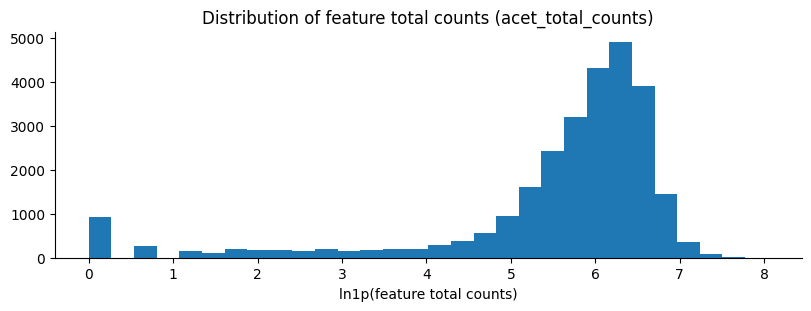

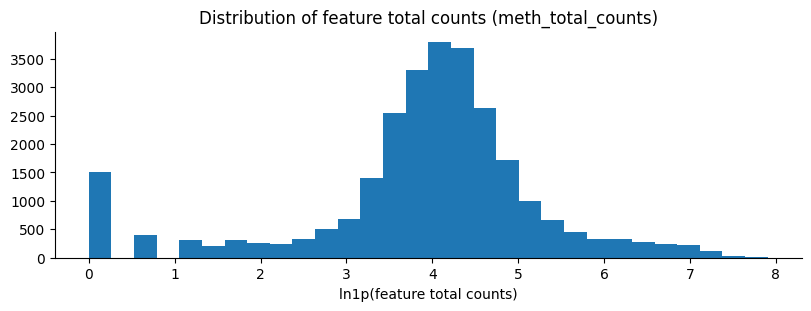

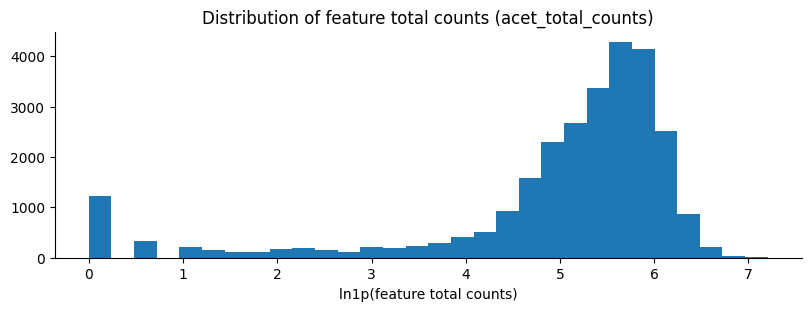

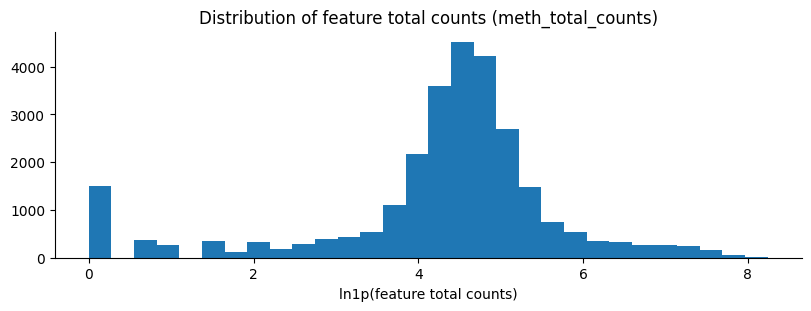

In [ ]:
scit.pl.counts_histogram(rep1, hist_type='feature')
scit.pl.counts_histogram(rep2, hist_type='feature')

In [4]:
rep1 = scit.tl.filter(
    rep1, ['acet', 'meth'], 
    min_obs_counts=[20, 10], 
    max_obs_counts=[99j, 99j], 
    return_purged=True
)
rep2 = scit.tl.filter(
    rep2, ['acet', 'meth'], 
    min_obs_counts=[20, 20], 
    max_obs_counts=[99j, 99j], 
    return_purged=True
)

Info: The 99.0th percentile of obs total counts is 4156.739999999947
Info: The 99.0th percentile of obs total counts is 1010.8199999999924
Info: The 99.0th percentile of obs total counts is 3306.7999999999884
Info: The 99.0th percentile of obs total counts is 1817.3999999999942


Info: Added acet counts metadata
Info: Added meth counts metadata
Info: Added acet counts metadata
Info: Added meth counts metadata


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


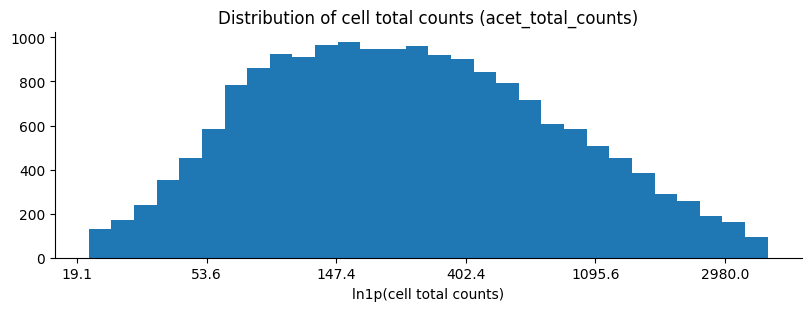

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


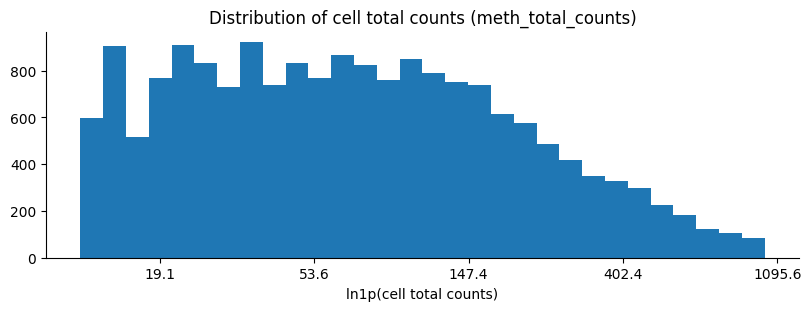

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


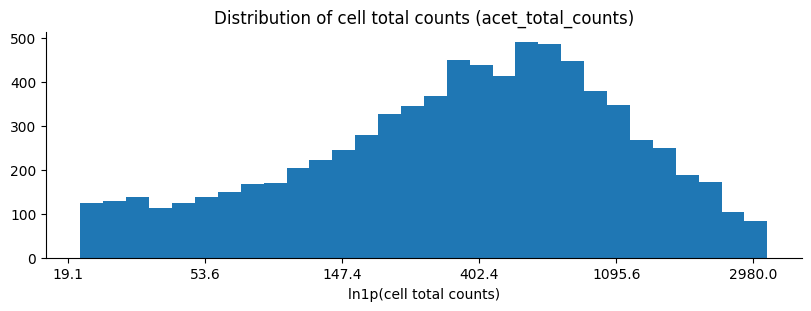

/home/aleksander-work/Skrivbord/pyproject/notebooks/src/plotting/_hist.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plw.ax.set_xticklabels(xticks)


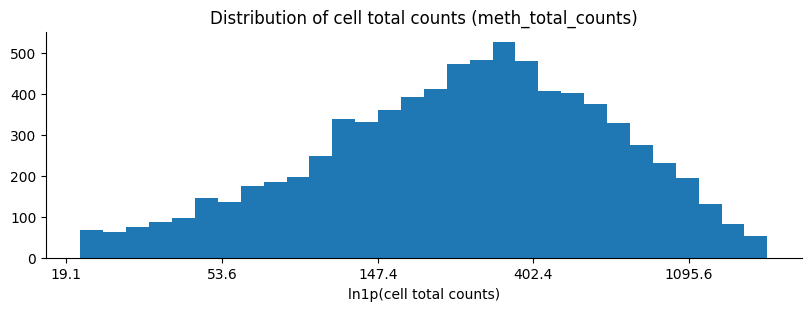

In [5]:
scit.tl.add_metadata(rep1, ['acet', 'meth'])
scit.tl.add_metadata(rep2, ['acet', 'meth'])
scit.set_defaults(figsize=(8,3))
scit.pl.counts_histogram(rep1, label_exp=True)
scit.pl.counts_histogram(rep2, label_exp=True)

In [6]:
assert np.unique([n[-1] for n in rep1.obs_names]).shape[0] == 1
assert np.unique([n[-1] for n in rep2.obs_names]).shape[0] == 1

rep1.obs['batch'] = 'batch1'
rep1.obs_names = [f"{n[:-2]}-e1" for n in rep1.obs_names]
rep2.obs_names = [f"{n[:-2]}-e2" for n in rep2.obs_names]
rep2.obs['batch'] = 'batch2'

# Same var
assert rep2.shape[1] == np.intersect1d(rep2.var_names, rep1.var_names).shape[0]

In [ ]:
adata = ad.concat([rep1, rep2])
assert (adata.var_names == rep1.var_names).all()
import pandas as pd
adata.obs['batch'] = pd.Categorical(adata.obs['batch'])
adata.obs['timep'] = '8_10h'
adata.obs['timep'] = pd.Categorical(adata.obs['timep'])
adata.var = rep1.var.copy()
scit.tl.add_metadata(adata, ['acet', 'meth'])

In [10]:
adata=scit.tl.filter(
   adata, ['acet', 'meth'], 
    min_var_counts=[1, 1], return_purged=True
)

In [11]:
# Soft filter
scit.tl.filter(
   adata, ['acet', 'meth'], 
    min_var_counts=[15, 15]
)

Info: Adata not modified. If you want to remove excluded cells and bins, use return_purged = True or remove them manually


In [12]:
layers = ['acet', 'meth']
layer_keys = ['X_acetylation', 'X_methylation']
scit.set_defaults(figsize=(12,5))

for i in range(len(layers)):
    print(scit.em.spectral(adata, layers[i]))
    adata.obsm[layer_keys[i]] = adata.obsm['X_spectral'].copy()
    del adata.obsm['X_spectral']
    scit.tl.remove_pc(adata, layer_keys[i], 0)

[1.         0.02408112 0.01728347 0.01559274 0.01514803 0.01486635
 0.01373838 0.0130638  0.01295657 0.01288574 0.01284692 0.0127753
 0.0127495  0.01272944 0.01270482 0.01268739 0.01266394 0.01265031
 0.01261805 0.01260162 0.01259029 0.01258063 0.01256634 0.01255024
 0.01253162]
[1.         0.0496404  0.04447004 0.03872701 0.03550122 0.03394642
 0.03383414 0.0335345  0.03339205 0.03311524 0.03307762 0.03291434
 0.03269418 0.03257578 0.03250212 0.03241344 0.0323437  0.03226566
 0.0322286  0.03216663 0.03203464 0.03187917 0.03185151 0.03180787
 0.03173013]


In [15]:
np.random.seed(0)
print(scit.em.multiview_spectral(adata, ['acet', 'meth'], random_seed=22))

[1.         0.04399695 0.02636199 0.0229089  0.01915542 0.01812645
 0.01731402 0.01682505 0.01653417 0.01626759 0.01614499 0.01601501
 0.01596502 0.01592106 0.01591306 0.01586392 0.01574294 0.0157339
 0.01568982 0.01563841 0.0155805  0.01552863 0.01549321 0.0154605
 0.01543901]


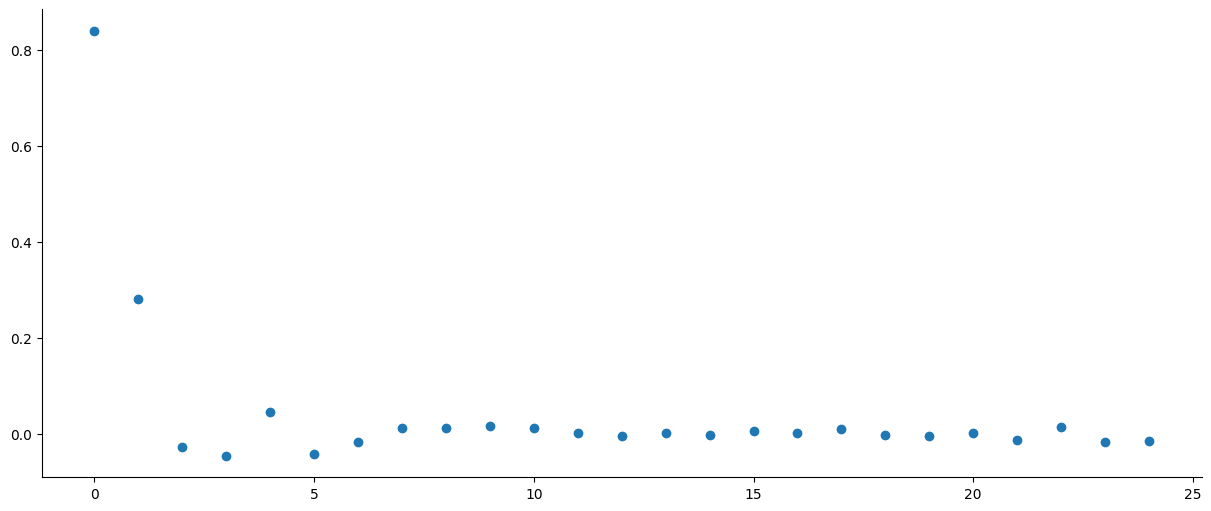

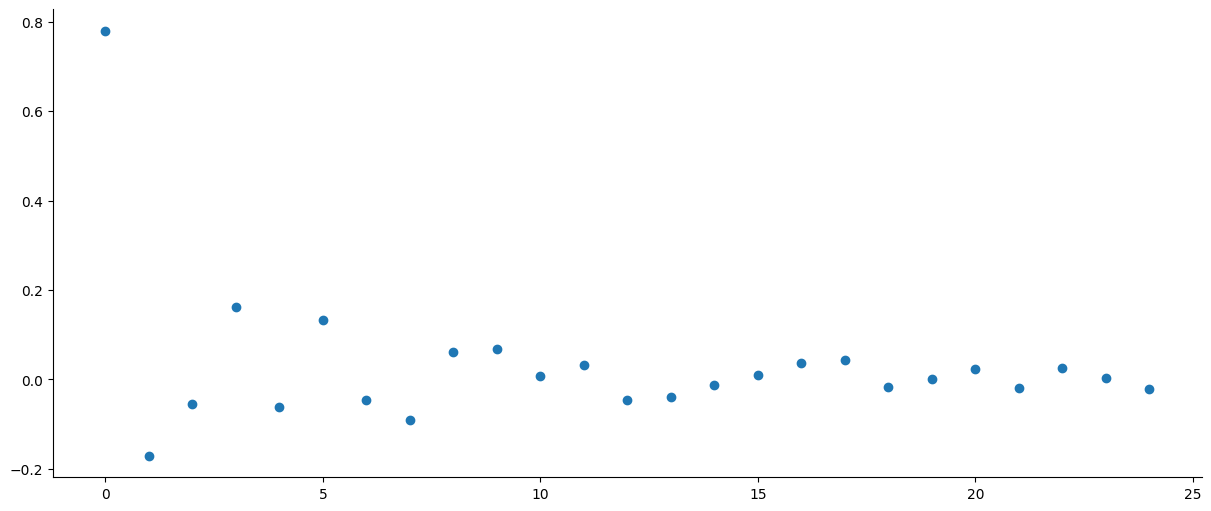

In [16]:
scit.pl.depth_corr(adata, 'X_multi_spectral', 'acet')
scit.pl.depth_corr(adata, 'X_multi_spectral', 'meth')

In [17]:
scit.tl.remove_pc(adata, 'X_multi_spectral', 0)

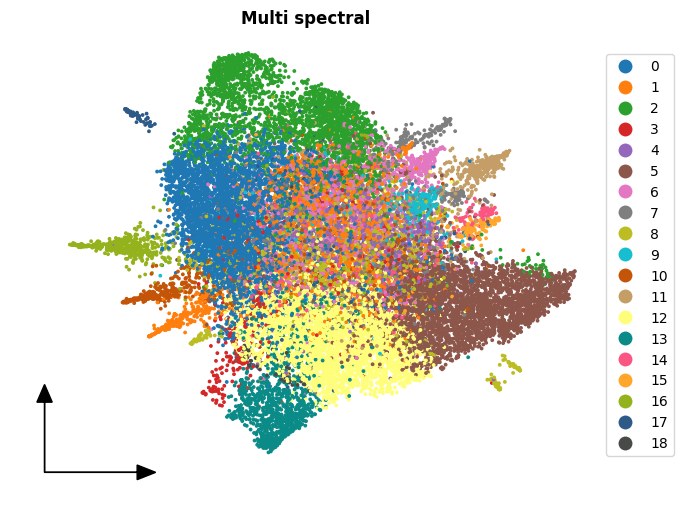

In [18]:
scit.em.umap(adata, 'X_multi_spectral', n_neighbors=10)
scit.gr.knn(adata, 'X_multi_spectral', n_neighbors=10)
scit.gr.leiden(adata, 1, obsp_key='connectivities')
scit.set_defaults(figsize=(6,5))
scit.pl.embedding2d(adata, 'X_umap', 'leiden', title=f'Multi spectral')

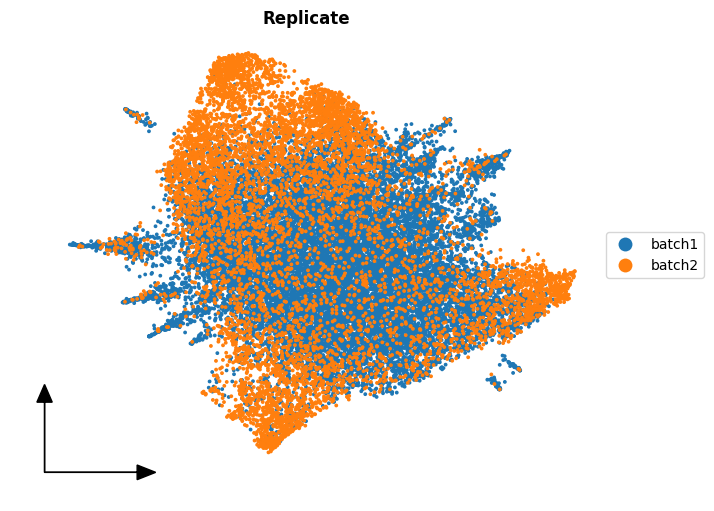

In [19]:
scit.pl.embedding2d(adata, 'X_umap', 'batch', title=f'Replicate')

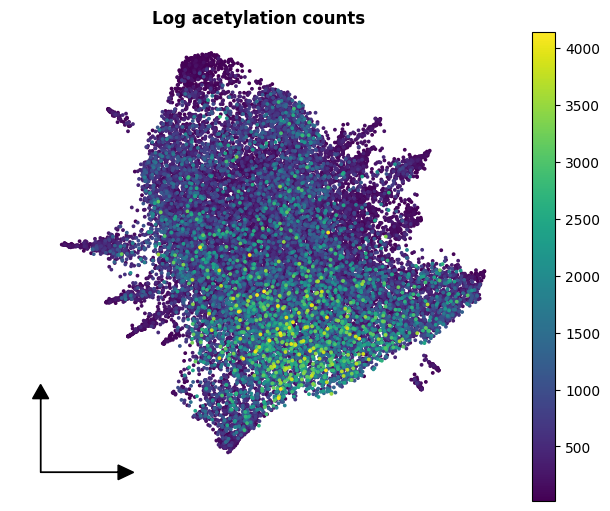

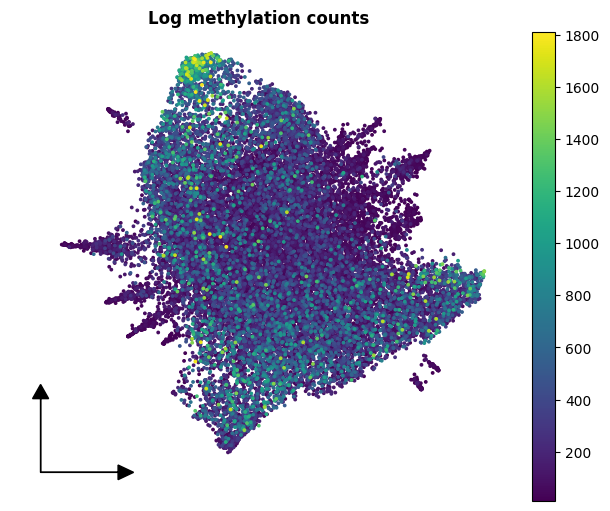

In [21]:
scit.pl.embedding2d(adata, 'X_umap', 'acet_total_counts', title='Log acetylation counts')
scit.pl.embedding2d(adata, 'X_umap', 'meth_total_counts', title='Log methylation counts')

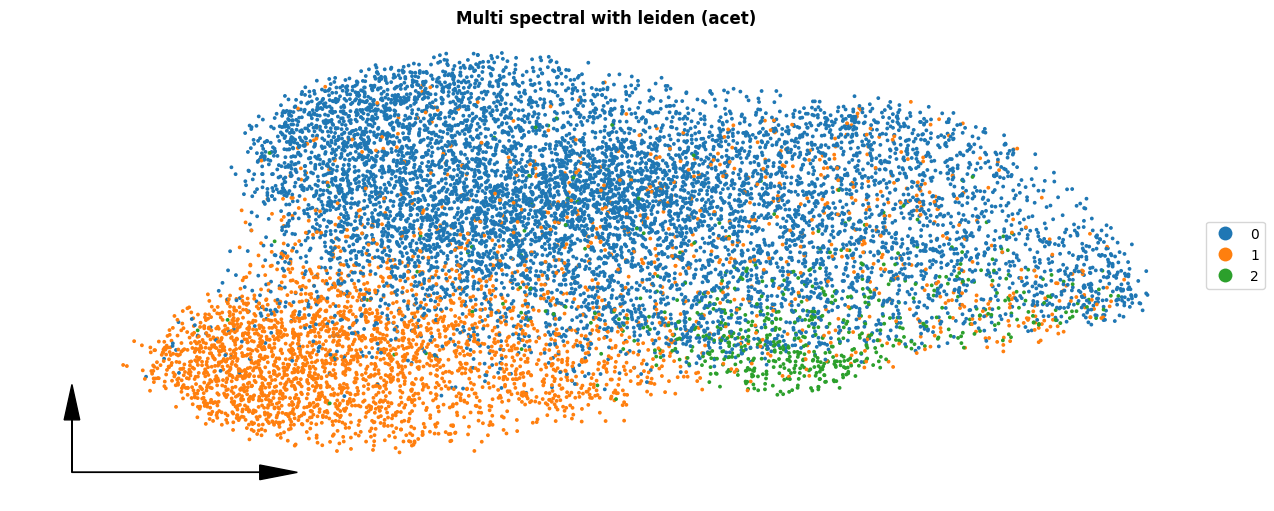

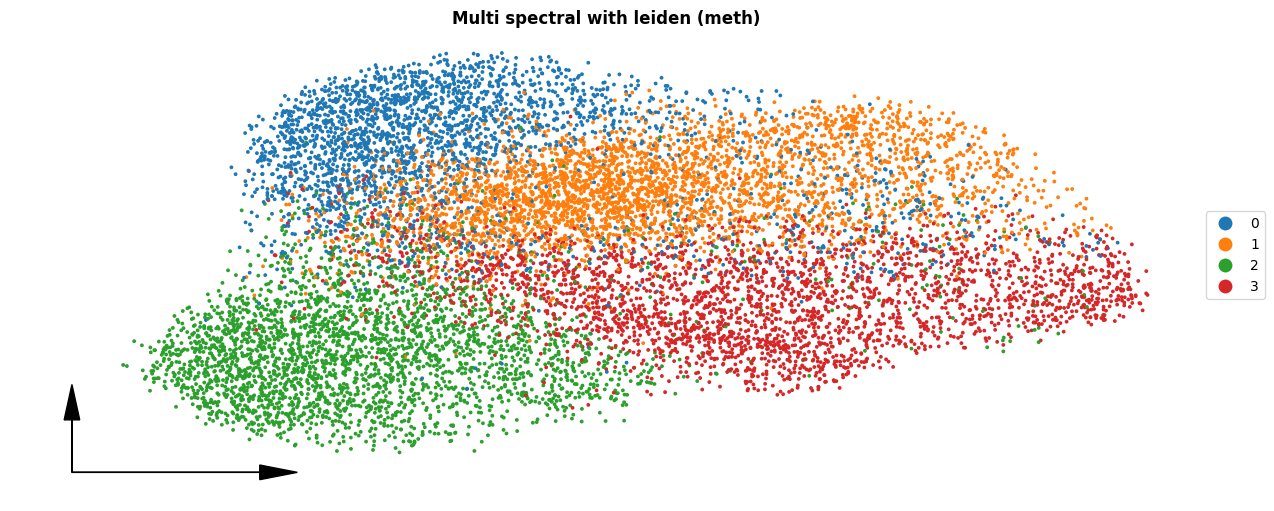

In [ ]:
for i in range(len(layers)):
    scit.gr.knn(adata, layer_keys[i], n_neighbors=50)
    scit.gr.leiden(adata, 0.5, obsp_key='connectivities')
    scit.pl.embedding2d(adata, 'X_umap', 'leiden', title=f'Multi spectral with leiden ({layers[i]})')

In [22]:
adata.write_h5ad('private/data/clean_method/early.h5ad')